In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

In [4]:
df= pd.read_excel(r'C:\Users\Dell\OneDrive\Documents\Sahil Arora Data Scientist\Telco-Customer-Churn.xlsx')

In [4]:
df_org= pd.read_excel(r'C:\Users\Dell\OneDrive\Documents\Sahil Arora Data Scientist\Telco-Customer-Churn.xlsx')

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)

df['TotalCharges'] = df['TotalCharges'].astype(float)
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

C:\Users\Dell\AppData\Local\Temp\ipykernel_9596\1267213483.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)


In [9]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df = df.dropna(subset = ['TotalCharges'])

In [13]:
df.shape

(7032, 21)

<Axes: xlabel='Churn', ylabel='count'>

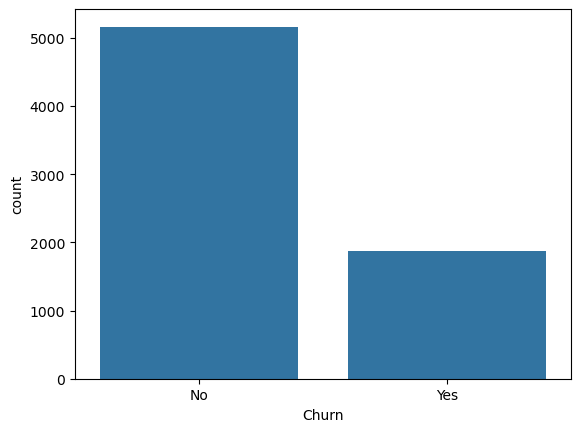

In [14]:
sns.countplot(data=df, x='Churn')

In [15]:
churnrate = df['Churn'].value_counts(normalize=True).mul(100).reset_index()
churnrate.columns = ['Churn', 'Churn_percent']

In [16]:
churnrate 

,Churn,Churn_percent
0,No,73.421502
1,Yes,26.578498


In [17]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [19]:
def plot_all_numeric_box_violin(df, label_col):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        if col == label_col:
            continue  # skip the label itself if it's numeric

        print(f"\n Visualizing: {col} vs {label_col}")

        plt.figure(figsize=(12, 5))

        # Boxplot
        plt.subplot(1, 2, 1)
        sns.boxplot(data=df, x=label_col, y=col)
        plt.title(f'Boxplot: {col} by {label_col}')

        # Violin plot
        plt.subplot(1, 2, 2)
        sns.violinplot(data=df, x=label_col, y=col)
        plt.title(f'Violin Plot: {col} by {label_col}')

        plt.tight_layout()



 Visualizing: tenure vs Churn

 Visualizing: MonthlyCharges vs Churn

 Visualizing: TotalCharges vs Churn


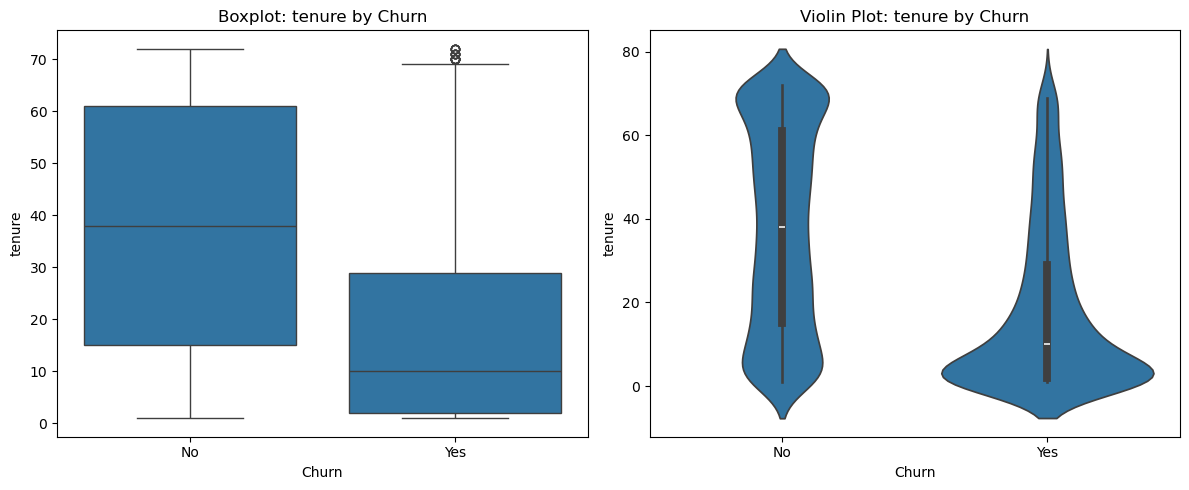

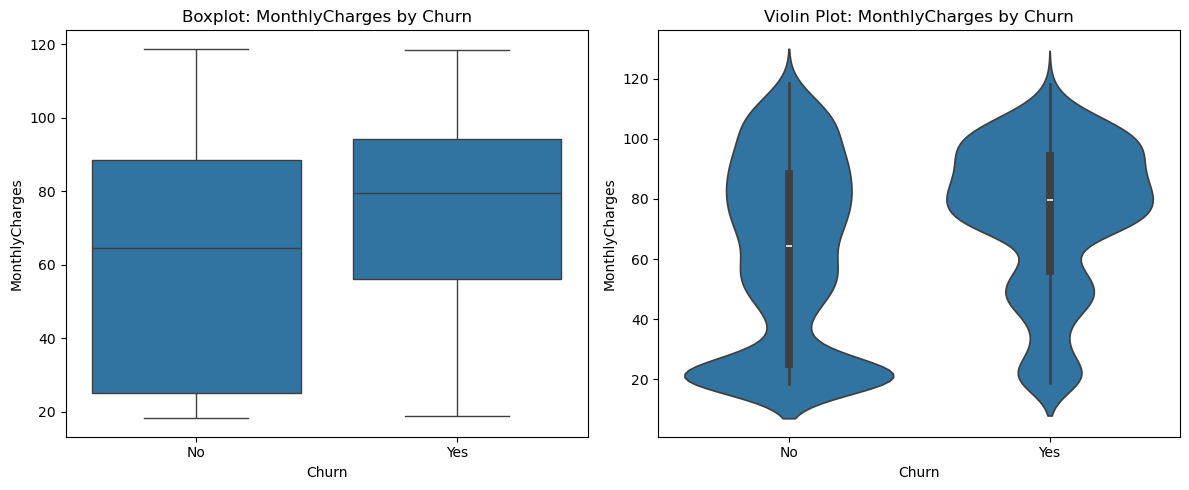

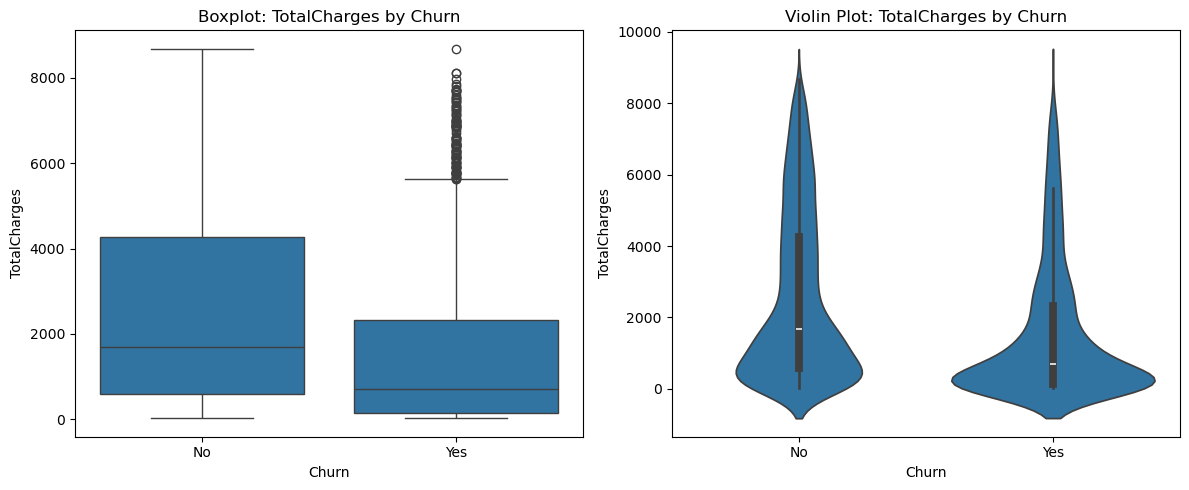

In [20]:
plot_all_numeric_box_violin(df, 'Churn')

In [21]:
df= df.drop('customerID',axis=1)

df.describe(include = 'object')

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


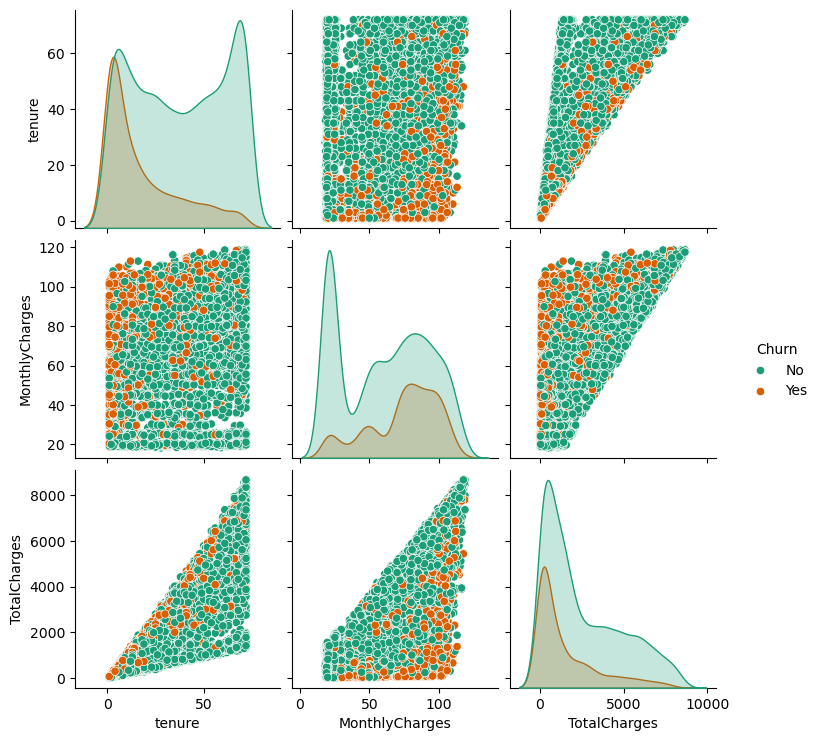

In [391]:
sns.pairplot(data = df_org, hue= 'Churn', palette='Dark2')

In [22]:
def analyze_categorical_vars(df, target_col):
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    
    for col in cat_cols:
        if col == target_col:
            continue  # skip the target variable itself
        
        print(f"\n📌 Variable: {col}")
        print("-" * 50)
        
        # Overall distribution
        print("\n▶ Overall Distribution (%):")
        print(df[col].value_counts(normalize=True).mul(100).round(2).reset_index().rename(
            columns={'index': col, col: 'Percentage'}))

        # Target distribution within each category
        print("\n▶ Target Distribution within each category (%):")
        print(df.groupby(col)[target_col].value_counts(normalize=True).mul(100).round(2).reset_index().rename(
            columns={target_col: 'Target_Value', 'count': 'Percentage'}))

        print("=" * 50)


In [23]:
analyze_categorical_vars(df, 'Churn')


📌 Variable: gender
--------------------------------------------------

▶ Overall Distribution (%):
  Percentage  proportion
0       Male       50.47
1     Female       49.53

▶ Target Distribution within each category (%):
   gender Target_Value  proportion
0  Female           No       73.04
1  Female          Yes       26.96
2    Male           No       73.80
3    Male          Yes       26.20

📌 Variable: SeniorCitizen
--------------------------------------------------

▶ Overall Distribution (%):
  Percentage  proportion
0          0       83.76
1          1       16.24

▶ Target Distribution within each category (%):
  SeniorCitizen Target_Value  proportion
0             0           No       76.35
1             0          Yes       23.65
2             1           No       58.32
3             1          Yes       41.68

📌 Variable: Partner
--------------------------------------------------

▶ Overall Distribution (%):
  Percentage  proportion
0         No       51.75
1        Yes  

# Senior citizen, No partner, No dependents, internet sevice(fiber optic), no online security, no online backup, no device protection, no tech support, contract type- month to month, paperless billing, payment method- electronic check,are more likely to discontinue the service.


In [25]:
df.groupby(['Partner','Dependents'])['Churn'].value_counts(normalize = True).mul(100).reset_index()

,Partner,Dependents,Churn,proportion
0,No,No,No,65.762195
1,No,No,Yes,34.237805
2,No,Yes,No,78.551532
3,No,Yes,Yes,21.448468
4,Yes,No,No,74.591652
5,Yes,No,Yes,25.408348
6,Yes,Yes,No,85.689655
7,Yes,Yes,Yes,14.310345


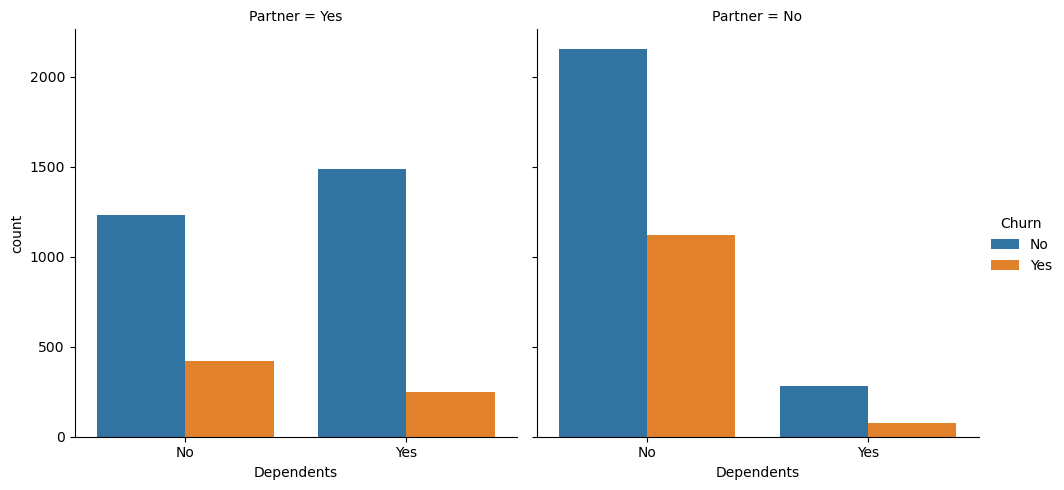

In [26]:
sns.catplot(data = df, x= 'Dependents', col = 'Partner', hue= 'Churn', kind= 'count')

In [27]:
df.groupby(['InternetService','OnlineSecurity'])['Churn'].value_counts(normalize = True).mul(100).reset_index()

,InternetService,OnlineSecurity,Churn,proportion
0,DSL,No,No,72.016129
1,DSL,No,Yes,27.983871
2,DSL,Yes,No,90.476190
3,DSL,Yes,Yes,9.523810
4,Fiber optic,No,No,50.642446
5,Fiber optic,No,Yes,49.357554
6,Fiber optic,Yes,No,78.188319
7,Fiber optic,Yes,Yes,21.811681
8,No,No internet service,No,92.565789
9,No,No internet service,Yes,7.434211


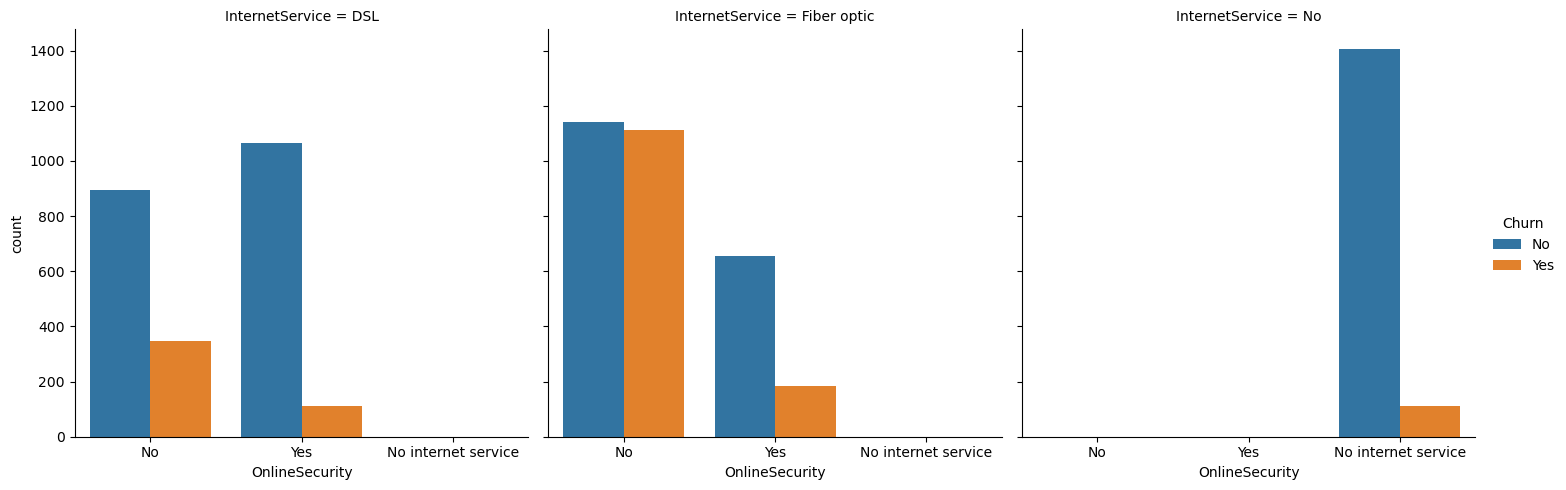

In [28]:
sns.catplot(data = df, x= 'OnlineSecurity', col = 'InternetService', hue= 'Churn', kind= 'count')

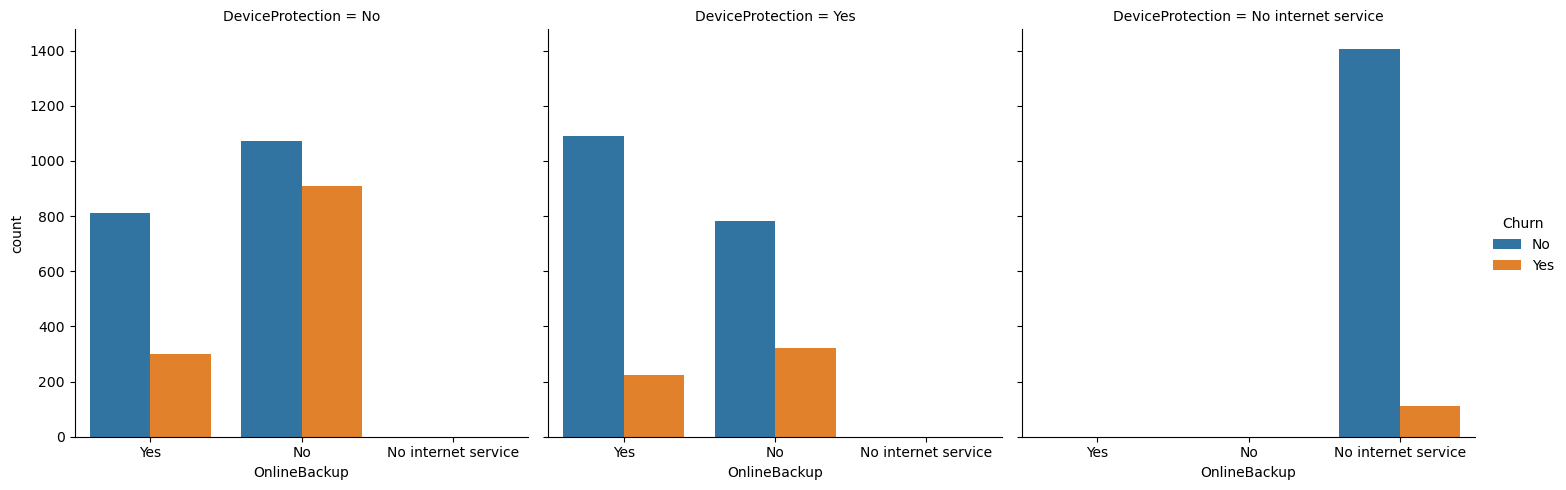

In [29]:
sns.catplot(data = df, x= 'OnlineBackup', col = 'DeviceProtection', hue= 'Churn', kind= 'count')

In [30]:
def chi_square_with_label(df, label_col, alpha=0.05):
    results = []

    for col in df.columns:
        if col != label_col and df[col].nunique() > 1:
            try:
                contingency = pd.crosstab(df[col], df[label_col])
                chi2, p, dof, _ = chi2_contingency(contingency)
                is_significant = "Yes" if p < alpha else "No"
                results.append({
                    'Variable': col,
                    'Chi2 Statistic': round(chi2, 4),
                    'p-value': round(p, 4),
                    'Degrees of Freedom': dof,
                    'Significant (p < 0.05)': is_significant
                })
            except Exception as e:
                results.append({
                    'Variable': col,
                    'Error': str(e)
                })

    return pd.DataFrame(results).sort_values('p-value')

In [31]:
df_obj = df.select_dtypes(include='object')

chi_square_with_label(df_obj, 'Churn', alpha=0.05)

,Variable,Chi2 Statistic,p-value,Degrees of Freedom,Significant (p < 0.05)
1,SeniorCitizen,158.4408,0.0000,1,Yes
2,Partner,157.5032,0.0000,1,Yes
3,Dependents,186.3216,0.0000,1,Yes
6,InternetService,728.6956,0.0000,2,Yes
7,OnlineSecurity,846.6774,0.0000,2,Yes
8,OnlineBackup,599.1752,0.0000,2,Yes
9,DeviceProtection,555.8803,0.0000,2,Yes
10,TechSupport,824.9256,0.0000,2,Yes
11,StreamingTV,372.4565,0.0000,2,Yes
12,StreamingMovies,374.2684,0.0000,2,Yes


# There is no association between phone service & churn, gender & churn

In [33]:
def t_test_with_binary_label(df, label_col, alpha=0.05):
    results = []

    # Get the two label values (assumes binary)
    unique_labels = df[label_col].dropna().unique()
    if len(unique_labels) != 2:
        raise ValueError("Label column must be binary for t-test.")

    group1_val, group2_val = unique_labels

    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        if col != label_col:
            try:
                group1 = df[df[label_col] == group1_val][col].dropna()
                group2 = df[df[label_col] == group2_val][col].dropna()
                
                t_stat, p_val = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
                is_significant = "Yes" if p_val < alpha else "No"
                
                results.append({
                    'Variable': col,
                    't-statistic': round(t_stat, 4),
                    'p-value': round(p_val, 4),
                    'Significant (p < 0.05)': is_significant
                })
            except Exception as e:
                results.append({
                    'Variable': col,
                    'Error': str(e)
                })

    return pd.DataFrame(results).sort_values('p-value')

In [34]:
t_test_with_binary_label(df, 'Churn', alpha=0.05)

,Variable,t-statistic,p-value,Significant (p < 0.05)
0,tenure,34.9719,0.0,Yes
1,MonthlyCharges,-18.3409,0.0,Yes
2,TotalCharges,18.8008,0.0,Yes


# The means are different for both groups in churn with respect to tenure, monthly charge, total charge

In [36]:

df= pd.get_dummies(data=df,drop_first=True)

In [37]:
df['Churn_Yes']

0       False
1       False
2        True
3       False
4        True
        ...  
7038    False
7039    False
7040    False
7041     True
7042    False
Name: Churn_Yes, Length: 7032, dtype: bool

In [39]:
df['Churn_Yes'] = df['Churn_Yes'].map({True:1, False:0})

In [40]:
df= df.rename(columns = {df.columns[-1]:'Churn'})

In [41]:
dfcorr = df.corr()['Churn'].sort_values()

In [42]:
dfcorr = dfcorr.iloc[:-1]

In [43]:
dfcorr = dfcorr.reset_index()
dfcorr.columns = ['features', 'churn_corr']


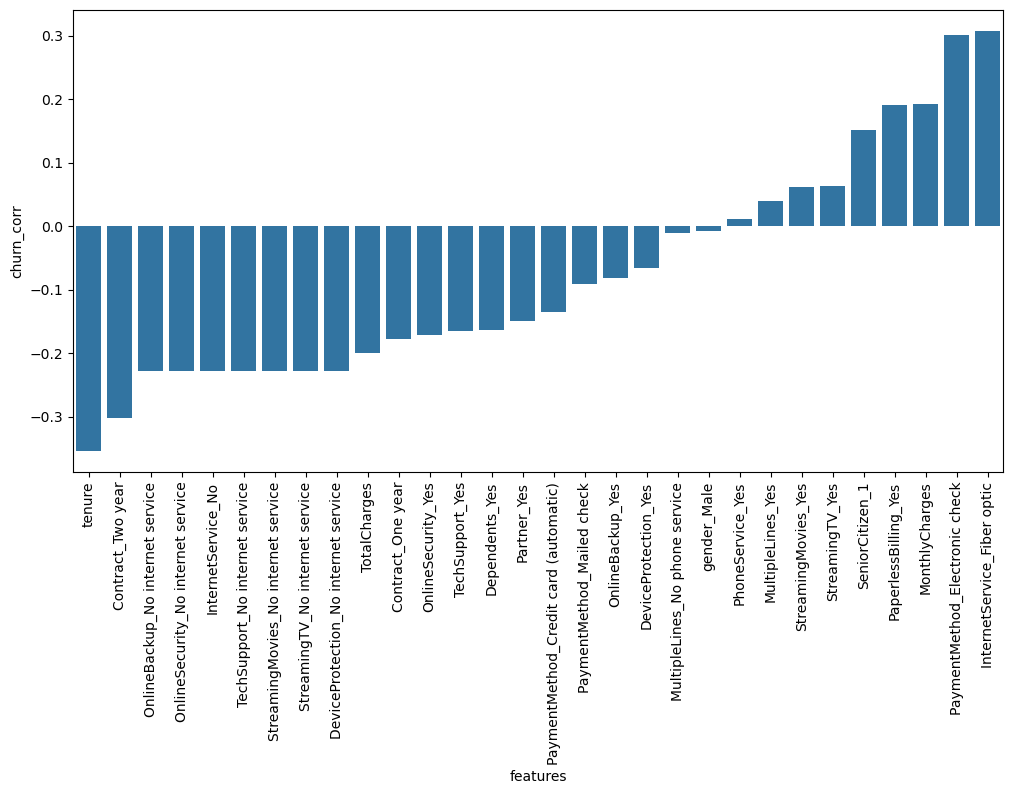

In [44]:
plt.figure(figsize = (12,6))
sns.barplot(data=dfcorr, x= 'features', y='churn_corr')
plt.xticks(rotation = 90);

# We are getting tenure, contract_two year as negative correlated, means, churn will decrease if tenure or contract_two year increases. alsp we can see positive correlation with internetservice fiber_optic and payment method_ electronic_check.

In [46]:
# churn_rate

def churn_rate(x):
    return 100* (x =='Yes').sum()/len(x)

In [47]:
df_ten_ch = df_org.groupby('tenure')['Churn'].apply(lambda x: churn_rate(x)).reset_index()



In [48]:
df_ten_ch = df_ten_ch.iloc[1:]

In [49]:
df_ten_ch.columns = ['Tenure_Month', 'Churn_Rate']

<Axes: xlabel='Tenure_Month', ylabel='Churn_Rate'>

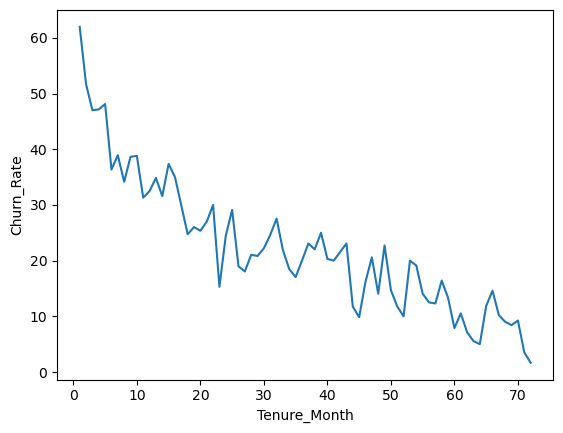

In [50]:
sns.lineplot(data= df_ten_ch, x= 'Tenure_Month', y = 'Churn_Rate')

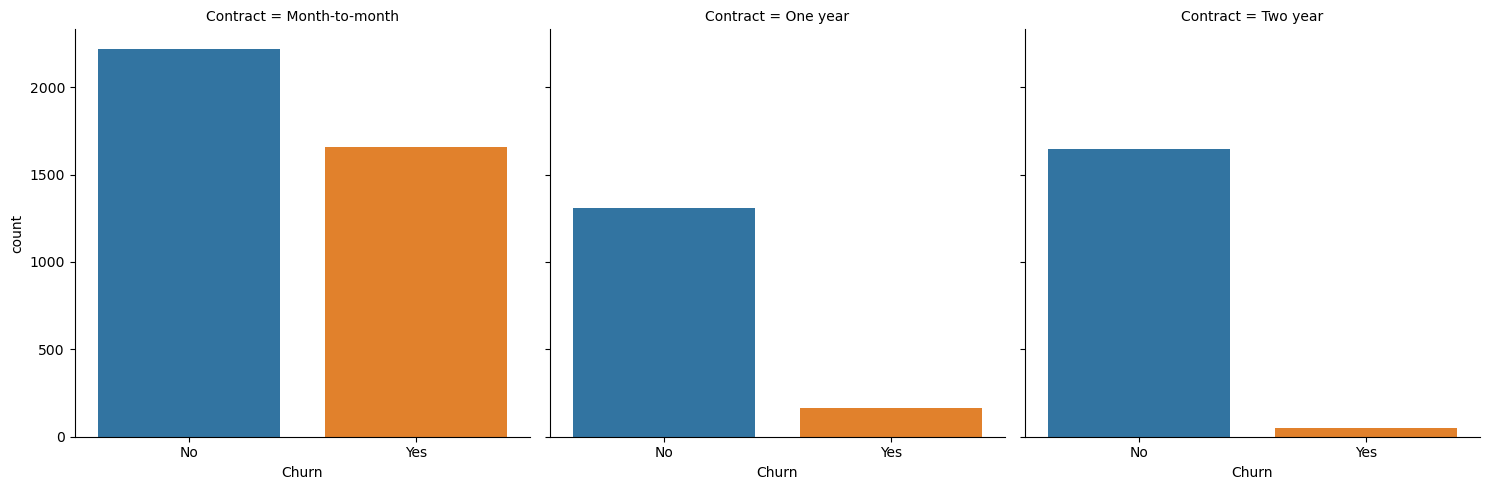

In [94]:
sns.catplot(data= df_org, x= 'Churn', kind= 'count', col = 'Contract', hue = 'Churn')

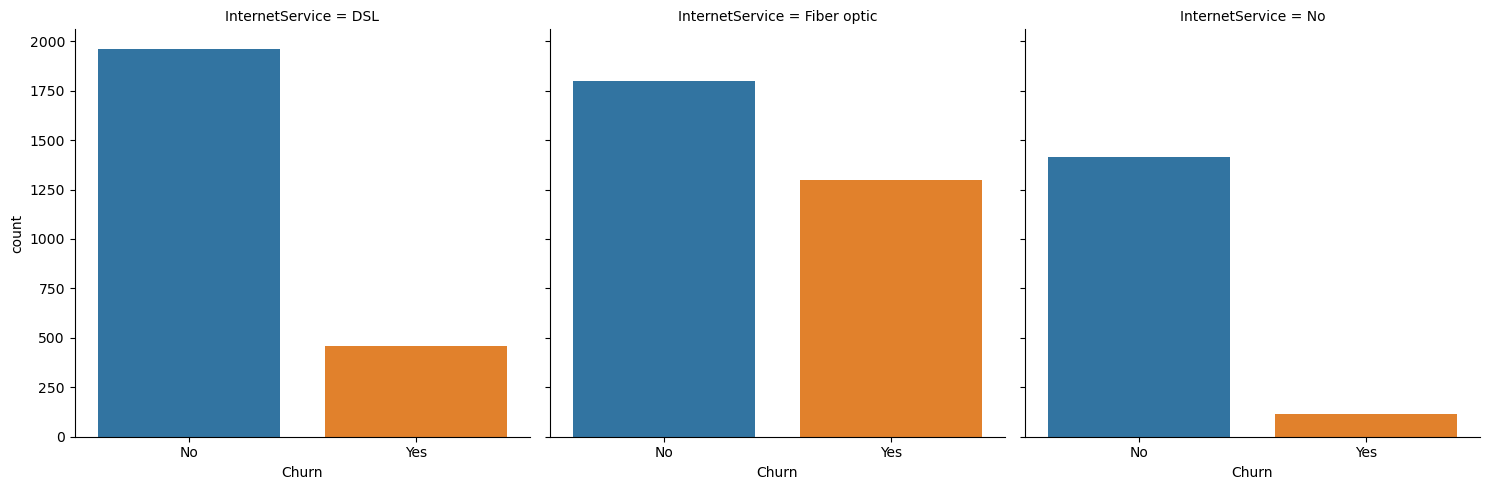

In [96]:
sns.catplot(data= df_org, x= 'Churn', kind= 'count', col = 'InternetService', hue = 'Churn')

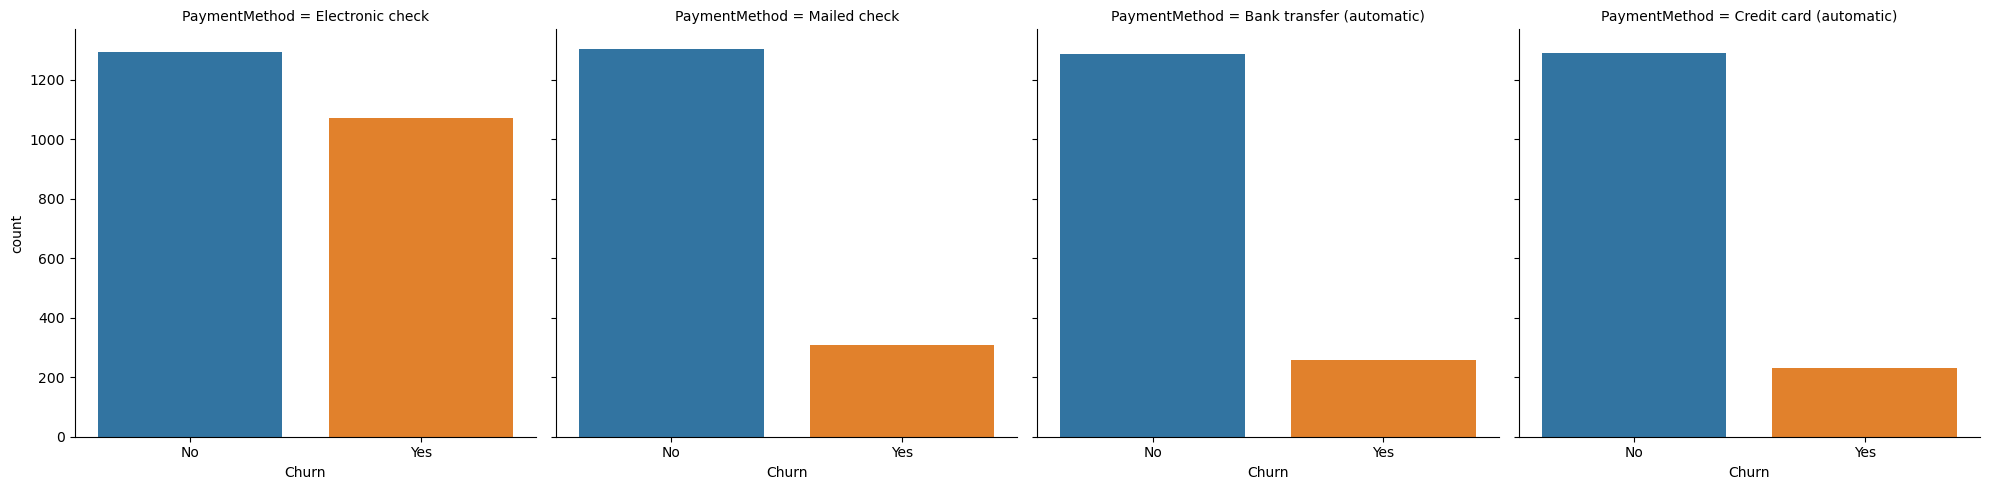

In [98]:
sns.catplot(data= df_org, x= 'Churn', kind= 'count', col = 'PaymentMethod', hue = 'Churn')

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

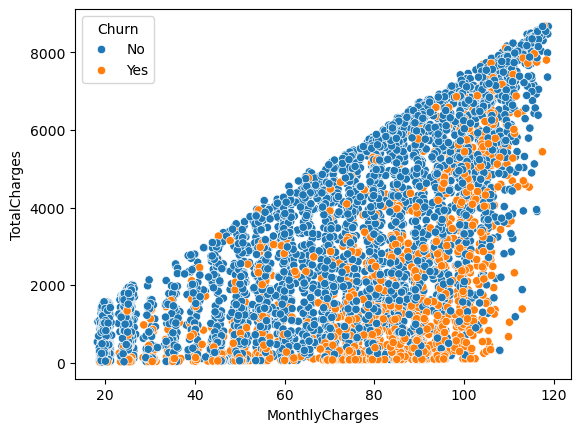

In [108]:
df_org['TotalCharges'] = df_org['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)

df_org['TotalCharges'] = df_org['TotalCharges'].astype(float)
df_org['SeniorCitizen'] = df_org['SeniorCitizen'].astype(str)

sns.scatterplot(data= df_org, x= 'MonthlyCharges', y = 'TotalCharges', hue = 'Churn')

# data says that if monthlyCharges are higher they are likly to churn at early stage

In [127]:
df_tenure_churn_mean = df.groupby(['tenure','Churn'])['MonthlyCharges'].mean().reset_index()

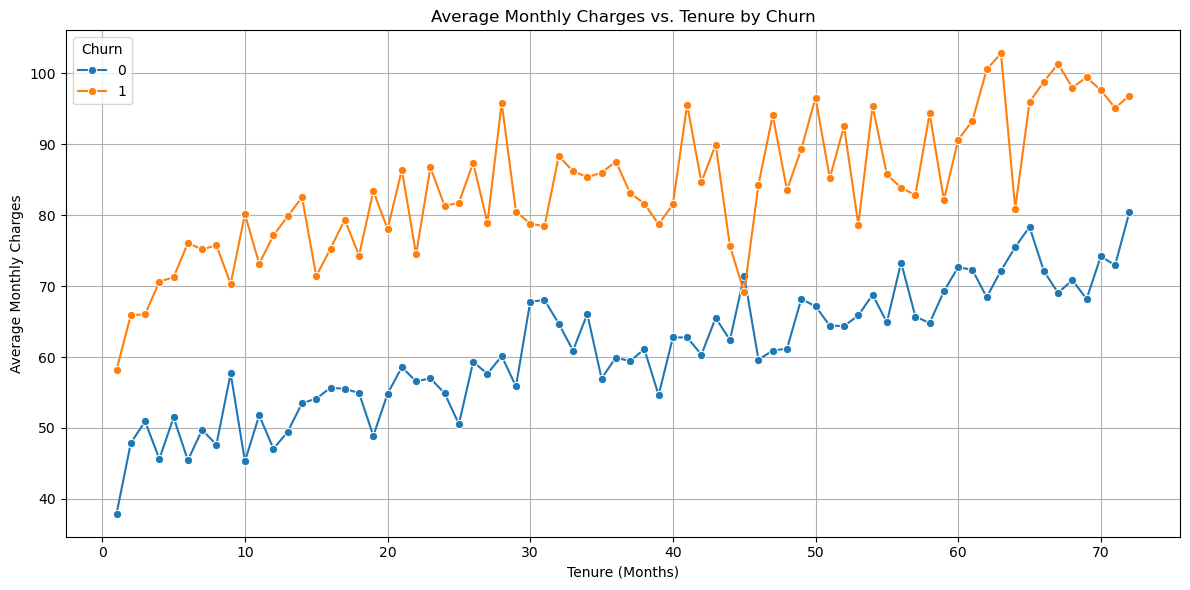

In [135]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_tenure_churn_mean, x='tenure', y='MonthlyCharges', hue='Churn', marker='o')

plt.title('Average Monthly Charges vs. Tenure by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Monthly Charges')
plt.legend(title='Churn')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
#tenure group

def tenure_group(x):
    if x<=12:
        return '1-12 months'
    elif x<=24:
        return '13-24 months'
    elif x<=36:
        return '25-36 months'
    elif x<=48:
        return '37-48 months'
    else:
        return 'more than 48 months'

In [15]:
df_org['tenure_group'] = df_org['tenure'].apply(lambda x: tenure_group(x))

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

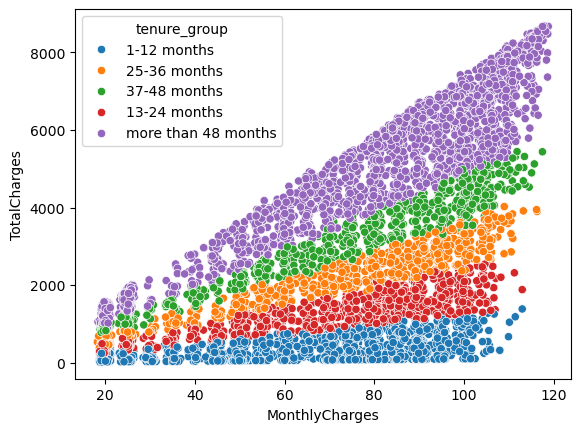

In [196]:
sns.scatterplot(data= df_org, x= 'MonthlyCharges', y = 'TotalCharges', hue= 'tenure_group')

In [17]:
#Get Dummies

df_org['TotalCharges'] = df_org['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)

df_org['TotalCharges'] = df_org['TotalCharges'].astype(float)
df_org['SeniorCitizen'] = df_org['SeniorCitizen'].astype(str)
df_org = df_org[df_org['tenure']!=0]
df_org['tenure_group'] = df_org['tenure'].apply(lambda x: tenure_group(x))

df_obj = df_org.select_dtypes(include = 'object')
df_num = df_org.select_dtypes(exclude = 'object')
df_churn = df_org['Churn']




In [19]:
df_obj=pd.get_dummies(df_obj.drop('Churn',axis=1),drop_first=True)


In [21]:
df_with_dum = pd.concat([df_obj, df_num,df_churn],axis=1)

# Machine Learning

# Train | Test Split and Scaling

In [136]:
X = df_with_dum.drop('Churn', axis=1)
y = df_with_dum['Churn']

# Logistic Regression

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [143]:
scaler =  StandardScaler()

In [145]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [346]:
from sklearn.linear_model import LogisticRegressionCV

# Without class balance

In [348]:
log_model = LogisticRegressionCV()

In [350]:
log_model.fit(X_train,y_train)

LogisticRegressionCV()

In [355]:
log_model.C_

array([2.7825594])

# Model Performance Evaluation

In [33]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [361]:
y_pred = log_model.predict(X_test)

In [363]:
confusion_matrix(y_test,y_pred)

array([[532,  25],
       [ 93,  54]], dtype=int64)

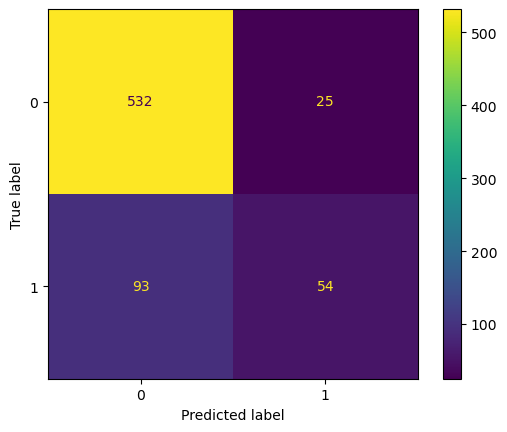

In [367]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

# With class balance - Class Weight

In [370]:
log_model_cw = LogisticRegressionCV(class_weight='balanced')

In [372]:
log_model_cw.fit(X_train,y_train)

LogisticRegressionCV(class_weight='balanced')

In [374]:
y_pred = log_model_cw.predict(X_test)

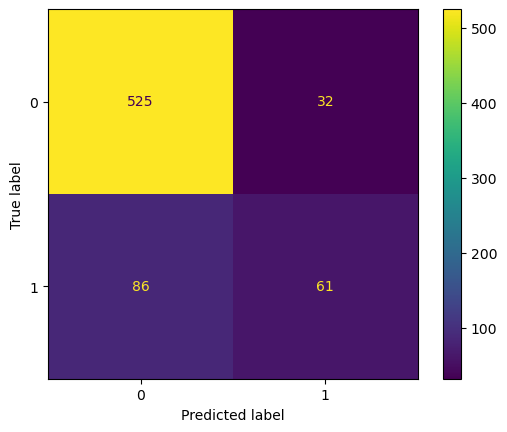

In [376]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

# With class balance -SMOTE

In [379]:
sm = SMOTE(random_state=101)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [380]:
log_model.fit(X_train_resampled, y_train_resampled)

LogisticRegressionCV()

In [381]:
y_pred = log_model.predict(X_test)

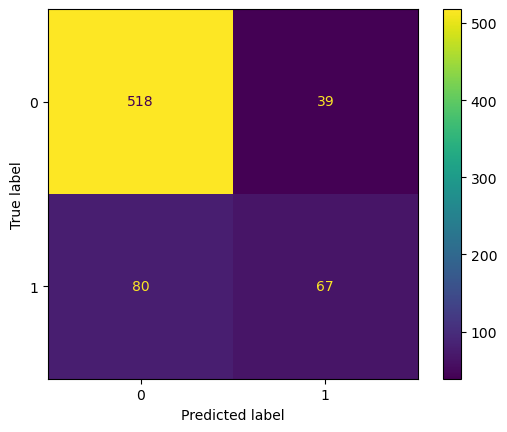

In [382]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

# '''Tree Based Models-
1. Descion tree
2. Random Forest
3. Ada boOsting
4. Gradient boOsting
5. xgboost'''

# Descion Tree

In [118]:
from sklearn.tree import DecisionTreeClassifier

In [425]:
model = DecisionTreeClassifier(class_weight= 'balanced')

In [427]:
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced')

In [428]:
base_pred = model.predict(X_test)

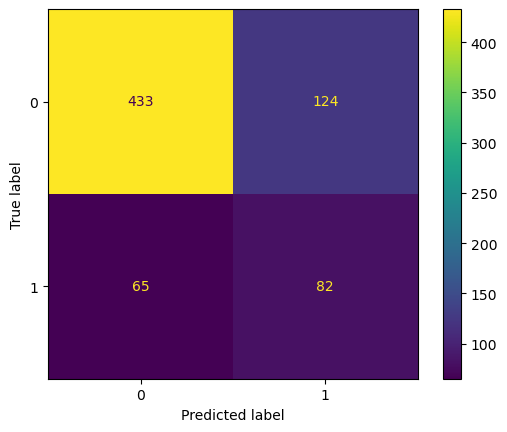

In [429]:
ConfusionMatrixDisplay(confusion_matrix(y_test,base_pred)).plot()

In [430]:
print(classification_report(y_test,base_pred))

              precision    recall  f1-score   support

          No       0.87      0.78      0.82       557
         Yes       0.40      0.56      0.46       147

    accuracy                           0.73       704
   macro avg       0.63      0.67      0.64       704
weighted avg       0.77      0.73      0.75       704



# Random Forest

In [437]:
from sklearn.ensemble import RandomForestClassifier

In [445]:
model = RandomForestClassifier()

In [43]:
from sklearn.model_selection import GridSearchCV

In [443]:
param_grid = {'n_estimators': [1,10,100,200],
            'max_features': ["auto", "sqrt", "log2"]}

In [447]:
grid_model = GridSearchCV(estimator = model,param_grid = param_grid )

In [449]:
grid_model.fit(X_train,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Dell\anaconda3\Lib\site-packages\sklea

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [1, 10, 100, 200]})

In [453]:
grid_model.best_params_

{'max_features': 'sqrt', 'n_estimators': 200}

In [455]:
y_pred = grid_model.predict(X_test)

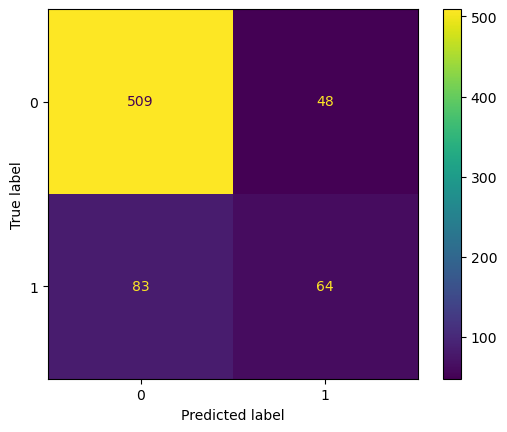

In [457]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

In [459]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.86      0.91      0.89       557
         Yes       0.57      0.44      0.49       147

    accuracy                           0.81       704
   macro avg       0.72      0.67      0.69       704
weighted avg       0.80      0.81      0.80       704



# Ada Boosting

In [35]:
from sklearn.ensemble import AdaBoostClassifier

In [37]:
model = AdaBoostClassifier(algorithm='SAMME')

In [39]:
param_grid = {
    'n_estimators': [50, 100, 200],         
    'learning_rate': [0.01, 0.1, 1.0]
}

In [45]:
grid_model = GridSearchCV(estimator = model,param_grid = param_grid )

In [47]:
grid_model.fit(X_train,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Dell\an

GridSearchCV(estimator=AdaBoostClassifier(),
             param_grid={'learning_rate': [0.01, 0.1, 1.0],
                         'n_estimators': [50, 100, 200]})

In [48]:
grid_model.best_params_

{'learning_rate': 1.0, 'n_estimators': 200}

In [49]:
y_pred = grid_model.predict(X_test)

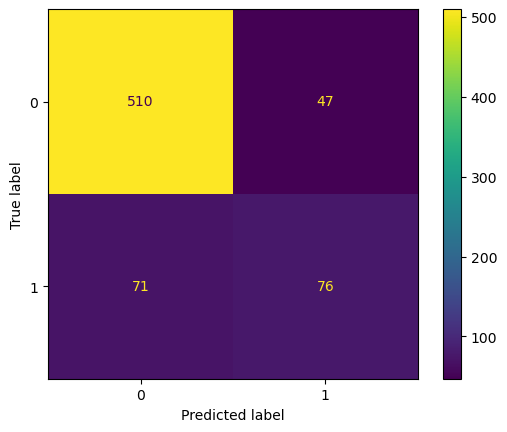

In [50]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90       557
         Yes       0.62      0.52      0.56       147

    accuracy                           0.83       704
   macro avg       0.75      0.72      0.73       704
weighted avg       0.82      0.83      0.83       704



# Gradient Boosting

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

In [54]:
param_grid = {"n_estimators":[1,5,10,20,40,100],'max_depth':[3,4,5,6]}

In [55]:
gb_model = GradientBoostingClassifier()

In [56]:
grid = GridSearchCV(gb_model,param_grid)

In [57]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [1, 5, 10, 20, 40, 100]})

In [58]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 40}

In [73]:
y_pred = grid.predict(X_test)

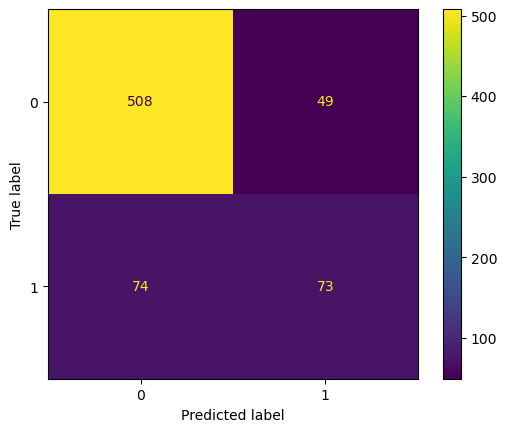

In [75]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

In [77]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.87      0.91      0.89       557
         Yes       0.60      0.50      0.54       147

    accuracy                           0.83       704
   macro avg       0.74      0.70      0.72       704
weighted avg       0.82      0.83      0.82       704



# XGBoosting

In [81]:
#!pip install xgboost


In [83]:
import xgboost as xgb

In [85]:
clf = xgb.XGBClassifier()

In [87]:
param_grid = {"n_estimators":[1,5,10,20,40,100],'max_depth':[3,4,5,6]}

In [89]:
grid = GridSearchCV(clf,param_grid)

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)


In [99]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [1, 5, 10, 20, 40, 100]})

In [100]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 20}

In [101]:
y_pred = grid.predict(X_test)

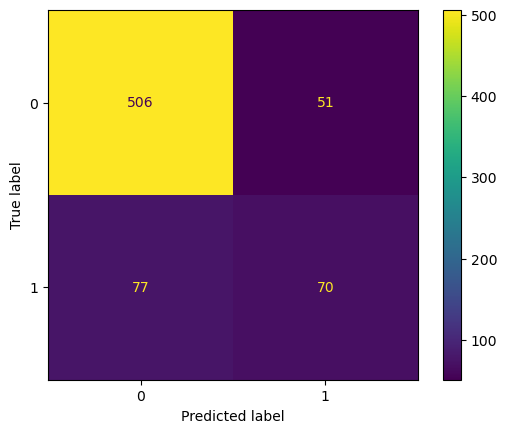

In [109]:
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred)).plot()

In [110]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       557
           1       0.58      0.48      0.52       147

    accuracy                           0.82       704
   macro avg       0.72      0.69      0.71       704
weighted avg       0.81      0.82      0.81       704



# Ada Boosting will give better results here.